In [ ]:
# =====================================================================
# 検証用コード: ハイブリッドモデル（Hybrid_CNN5_FC）100epアニーリング版
# 異常スコア: SSIM Top-K vs MSE Top-K の比較検証用
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (Hybrid_CNN5_FC版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        h = self.encoder_fc(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4)
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群 (SSIM vs MSE 比較仕様)
# =====================================================================
def evaluate_dataset(model, test_dir, device, threshold_ssim, threshold_mse, top_k=130):
    """データセット全体を推論し、SSIMとMSE両方の評価結果を返す"""
    model.eval()
    y_true = []
    
    # SSIM用リスト
    y_pred_ssim, scores_ssim = [], []
    # MSE用リスト
    y_pred_mse, scores_mse = [], []
    
    all_image_paths = []
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}")

    print(f"テストデータ全件の評価を開始します... (Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir(): continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            
            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                
                recon_tensor, _, _ = model(input_tensor)
                
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()
                
                # --- SSIMの計算 ---
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map_ssim = 1.0 - ssim_map
                top_k_score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
                
                # --- MSEの計算 ---
                # ピクセルごとの二乗誤差を計算
                anomaly_map_mse = (input_img - recon_img) ** 2
                top_k_score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
                
                # それぞれの閾値で判定
                pred_ssim = 1 if top_k_score_ssim > threshold_ssim else 0
                pred_mse = 1 if top_k_score_mse > threshold_mse else 0
                
                y_true.append(true_label)
                all_image_paths.append(img_path)
                
                y_pred_ssim.append(pred_ssim)
                scores_ssim.append(top_k_score_ssim)
                
                y_pred_mse.append(pred_mse)
                scores_mse.append(top_k_score_mse)
                
    print("評価が完了しました。")
    return (np.array(y_true), np.array(y_pred_ssim), np.array(scores_ssim), 
            np.array(y_pred_mse), np.array(scores_mse), all_image_paths)

def print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, th_ssim, th_mse, top_k):
    """SSIMとMSEの評価指標を計算し、混同行列を並べて描画する"""
    
    # 指標の計算関数
    def calc_metrics(y_t, y_p):
        return {
            'acc': accuracy_score(y_t, y_p) * 100,
            'prec': precision_score(y_t, y_p, zero_division=0) * 100,
            'rec': recall_score(y_t, y_p, zero_division=0) * 100,
            'f1': f1_score(y_t, y_p, zero_division=0) * 100
        }
    
    m_ssim = calc_metrics(y_true, y_pred_ssim)
    m_mse = calc_metrics(y_true, y_pred_mse)
    
    print(f"\n{'='*40}")
    print(f"定量評価結果 (Top-{top_k} パッチ)")
    print(f"{'='*40}")
    print(f"[SSIM 異常検知] 閾値: {th_ssim}")
    print(f" - 正解率 (Accuracy) : {m_ssim['acc']:.2f}%")
    print(f" - 適合率 (Precision): {m_ssim['prec']:.2f}%")
    print(f" - 再現率 (Recall)   : {m_ssim['rec']:.2f}%")
    print(f" - F値    (F1-score) : {m_ssim['f1']:.2f}%")
    print("-" * 40)
    print(f"[MSE 異常検知] 閾値: {th_mse}")
    print(f" - 正解率 (Accuracy) : {m_mse['acc']:.2f}%")
    print(f" - 適合率 (Precision): {m_mse['prec']:.2f}%")
    print(f" - 再現率 (Recall)   : {m_mse['rec']:.2f}%")
    print(f" - F値    (F1-score) : {m_mse['f1']:.2f}%")
    print(f"{'='*40}\n")
    
    # 混同行列の描画
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_ssim = confusion_matrix(y_true, y_pred_ssim)
    sns.heatmap(cm_ssim, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    axes[0].set_title(f"混同行列 [SSIM]\n(Acc: {m_ssim['acc']:.1f}% | F1: {m_ssim['f1']:.1f}%)", fontsize=16)
    axes[0].set_xlabel('AIの予測')
    axes[0].set_ylabel('実際の正解')
    
    cm_mse = confusion_matrix(y_true, y_pred_mse)
    sns.heatmap(cm_mse, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    axes[1].set_title(f"混同行列 [MSE]\n(Acc: {m_mse['acc']:.1f}% | F1: {m_mse['f1']:.1f}%)", fontsize=16)
    axes[1].set_xlabel('AIの予測')
    axes[1].set_ylabel('実際の正解')
    
    plt.tight_layout()
    plt.show()

def plot_score_distributions(y_true, scores_ssim, scores_mse, th_ssim, th_mse, top_k):
    """SSIMとMSEのスコア分布を並べて描画する"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    def plot_hist(ax, scores, th, title, xlabel, color_normal, color_anomaly, th_color):
        norm_scores = scores[y_true == 0]
        anom_scores = scores[y_true == 1]
        bins = np.linspace(np.min(scores), np.max(scores), 40)
        
        sns.histplot(norm_scores, bins=bins, color=color_normal, alpha=0.5, label='正常 (Good)', kde=False, ax=ax)
        sns.histplot(anom_scores, bins=bins, color=color_anomaly, alpha=0.5, label='異常 (Anomaly)', kde=False, ax=ax)
        ax.axvline(x=th, color=th_color, linestyle='--', linewidth=2, label=f'閾値 ({th})')
        
        ax.set_title(title, fontsize=15, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("画像の数", fontsize=12)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plot_hist(axes[0], scores_ssim, th_ssim, f"SSIM 異常スコア分布 (Top-{top_k})", "異常スコア (1-SSIM)", 'green', 'red', 'blue')
    plot_hist(axes[1], scores_mse, th_mse, f"MSE 異常スコア分布 (Top-{top_k})", "異常スコア (MSE)", 'teal', 'orange', 'red')
    
    plt.tight_layout()
    plt.show()

def plot_anomaly_comparison(model, image_path, device, th_ssim, th_mse, top_k=130):
    """1枚の画像に対し、SSIMとMSEの異常度マップを比較表示する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)
        
    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()
    
    # SSIM計算
    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map_ssim = 1.0 - ssim_map
    score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
    judgement_ssim = "異常" if score_ssim > th_ssim else "正常"
    color_ssim = 'red' if score_ssim > th_ssim else 'green'
    
    # MSE計算
    anomaly_map_mse = (input_img - recon_img) ** 2
    score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
    judgement_mse = "異常" if score_mse > th_mse else "正常"
    color_mse = 'red' if score_mse > th_mse else 'green'

    # 描画
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"比較: {image_path.name} (実際の正解: {image_path.parent.name})", fontsize=18, fontweight='bold')
    
    # ①入力
    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像", fontsize=14)
    axes[0].axis('off')
    
    # ②復元
    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')
    
    # ③SSIMマップ
    vmax_ssim = max(np.max(anomaly_map_ssim), 0.1)
    im3 = axes[2].imshow(anomaly_map_ssim, cmap='jet', vmin=0, vmax=vmax_ssim)
    axes[2].set_title(f"③ SSIM 異常度マップ\nスコア: {score_ssim:.4f} [{judgement_ssim}]", fontsize=14, color=color_ssim)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    # ④MSEマップ
    vmax_mse = max(np.max(anomaly_map_mse), 0.05) # MSEは値が小さいため上限を調整
    im4 = axes[3].imshow(anomaly_map_mse, cmap='jet', vmin=0, vmax=vmax_mse)
    axes[3].set_title(f"④ MSE 異常度マップ\nスコア: {score_mse:.4f} [{judgement_mse}]", fontsize=14, color=color_mse)
    axes[3].axis('off')
    fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")
    
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"
    
    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}")
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"モデルの重みを読み込みました。\n")
    
    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    
    # -------------------------------------------------------------
    # ★ パラメータ設定 ★
    # MSEのスケールはSSIMよりかなり小さい（0.01〜0.05程度）ことが多いです。
    # ヒストグラムの分布を見て、適宜調整してください。
    # -------------------------------------------------------------
    TOP_K = 130
    THRESHOLD_SSIM = 0.9
    THRESHOLD_MSE = 0.03  # 要調整: MSE用の閾値
    
    # 評価実行
    (y_true, y_pred_ssim, scores_ssim, 
     y_pred_mse, scores_mse, all_image_paths) = evaluate_dataset(
         model, TEST_DIR, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)
    
    # 定量評価と混同行列
    print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    # スコア分布比較
    plot_score_distributions(y_true, scores_ssim, scores_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    print("\n--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---")
    # 正常・異常からそれぞれランダムに表示
    normal_paths = [p for t, p in zip(y_true, all_image_paths) if t == 0]
    anomaly_paths = [p for t, p in zip(y_true, all_image_paths) if t == 1]
    
    sample_paths = []
    if normal_paths: sample_paths.extend(random.sample(normal_paths, min(2, len(normal_paths))))
    if anomaly_paths: sample_paths.extend(random.sample(anomaly_paths, min(3, len(anomaly_paths))))
    
    for img_path in sample_paths:
        plot_anomaly_comparison(model, img_path, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cpu


RuntimeError: Error(s) in loading state_dict for VAE_Hybrid_CNN_FC:
	Missing key(s) in state_dict: "encoder_conv.0.weight", "encoder_conv.0.bias", "encoder_conv.1.weight", "encoder_conv.1.bias", "encoder_conv.1.running_mean", "encoder_conv.1.running_var", "encoder_conv.3.weight", "encoder_conv.3.bias", "encoder_conv.4.weight", "encoder_conv.4.bias", "encoder_conv.4.running_mean", "encoder_conv.4.running_var", "encoder_conv.6.weight", "encoder_conv.6.bias", "encoder_conv.7.weight", "encoder_conv.7.bias", "encoder_conv.7.running_mean", "encoder_conv.7.running_var", "encoder_conv.9.weight", "encoder_conv.9.bias", "encoder_conv.10.weight", "encoder_conv.10.bias", "encoder_conv.10.running_mean", "encoder_conv.10.running_var", "encoder_conv.12.weight", "encoder_conv.12.bias", "encoder_conv.13.weight", "encoder_conv.13.bias", "encoder_conv.13.running_mean", "encoder_conv.13.running_var", "encoder_fc.0.weight", "encoder_fc.0.bias", "encoder_fc.2.weight", "encoder_fc.2.bias", "encoder_fc.4.weig

使用デバイス: cpu
モデルの重みを読み込みました。

テストデータ全件の評価を開始します... (Top-K: 130)
評価が完了しました。

定量評価結果 (Top-130 パッチ)
[SSIM 異常検知] 閾値: 0.9
 - 正解率 (Accuracy) : 91.57%
 - 適合率 (Precision): 96.67%
 - 再現率 (Recall)   : 92.06%
 - F値    (F1-score) : 94.31%
----------------------------------------
[MSE 異常検知] 閾値: 0.1
 - 正解率 (Accuracy) : 78.31%
 - 適合率 (Precision): 95.92%
 - 再現率 (Recall)   : 74.60%
 - F値    (F1-score) : 83.93%



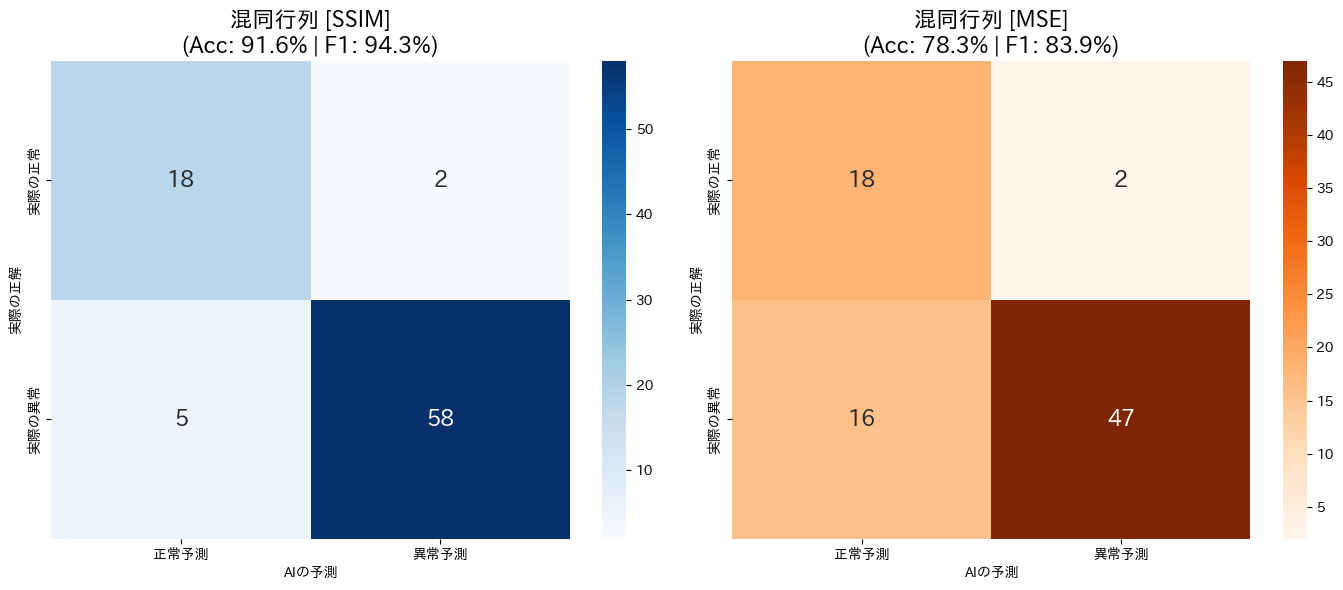

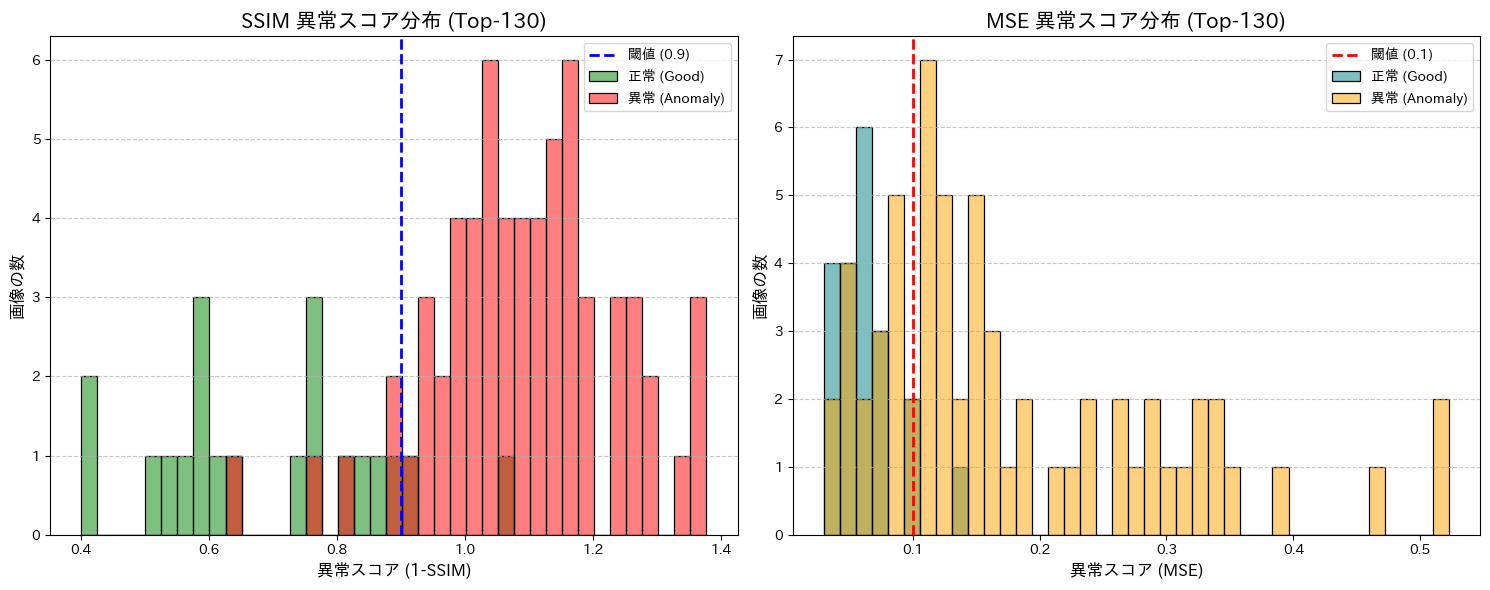


--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---


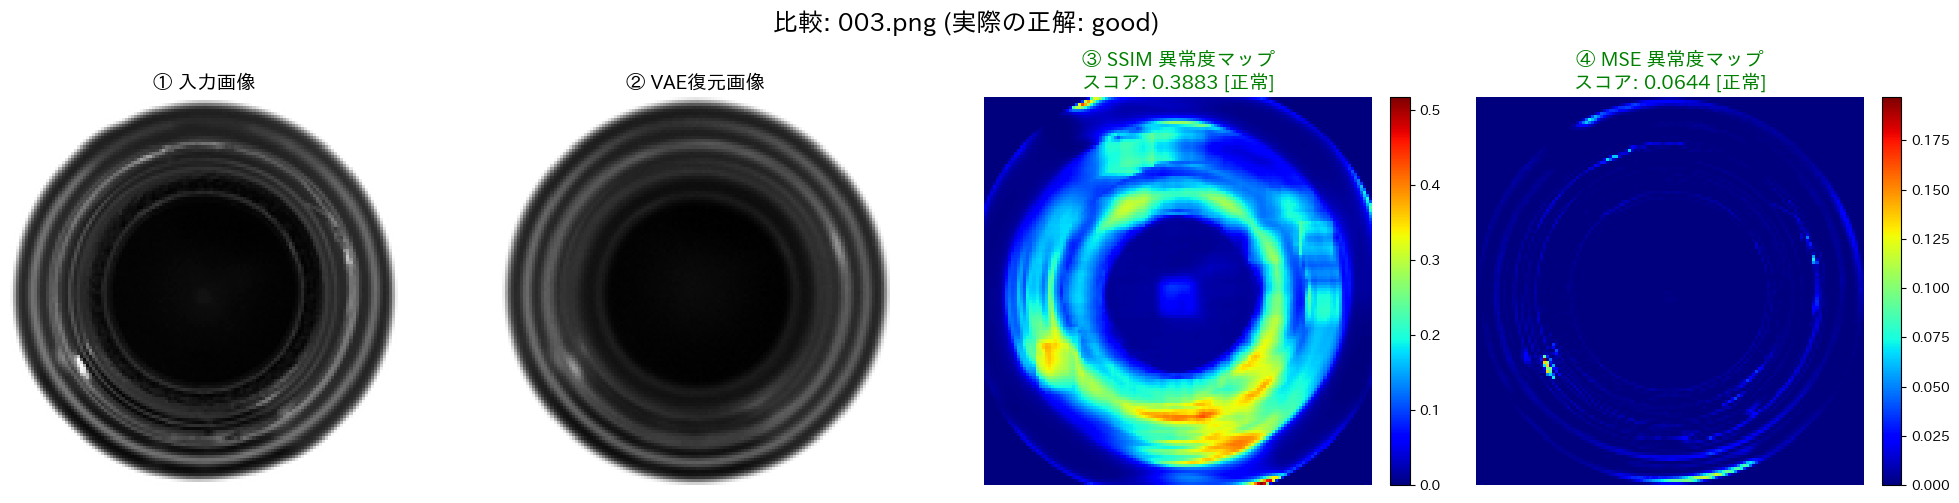

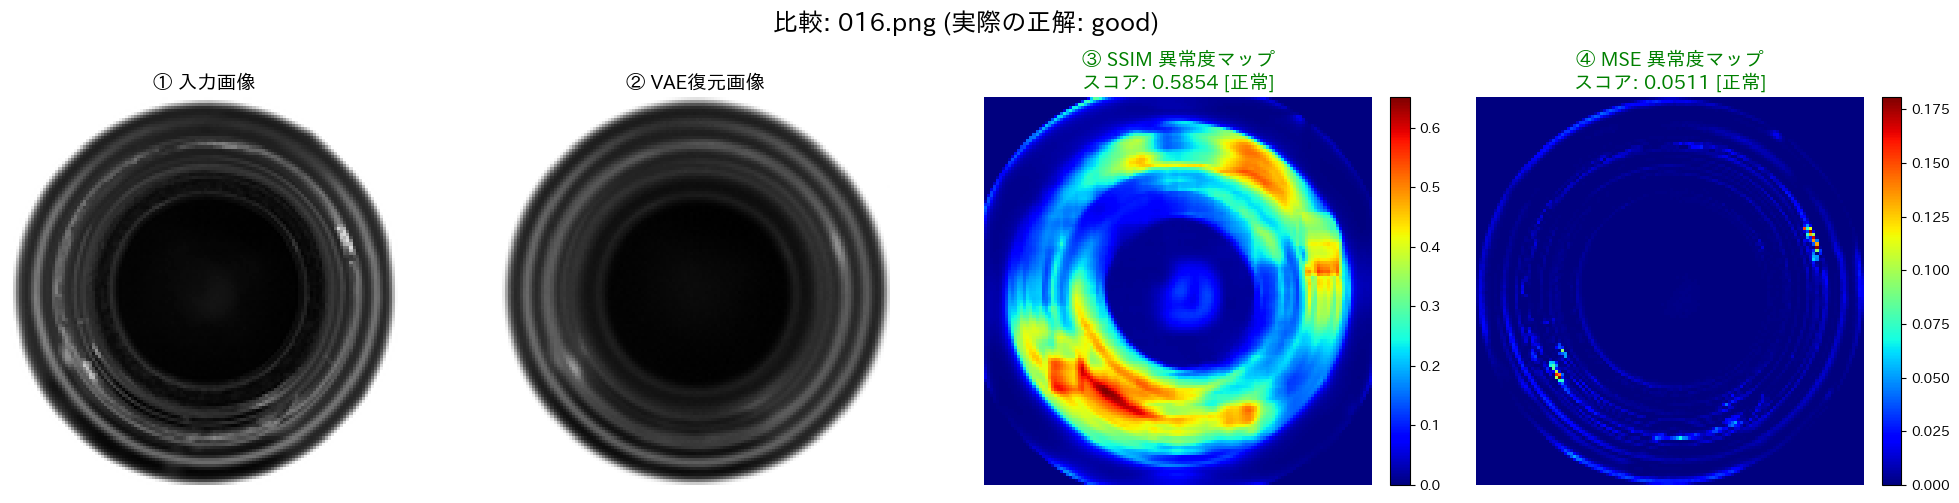

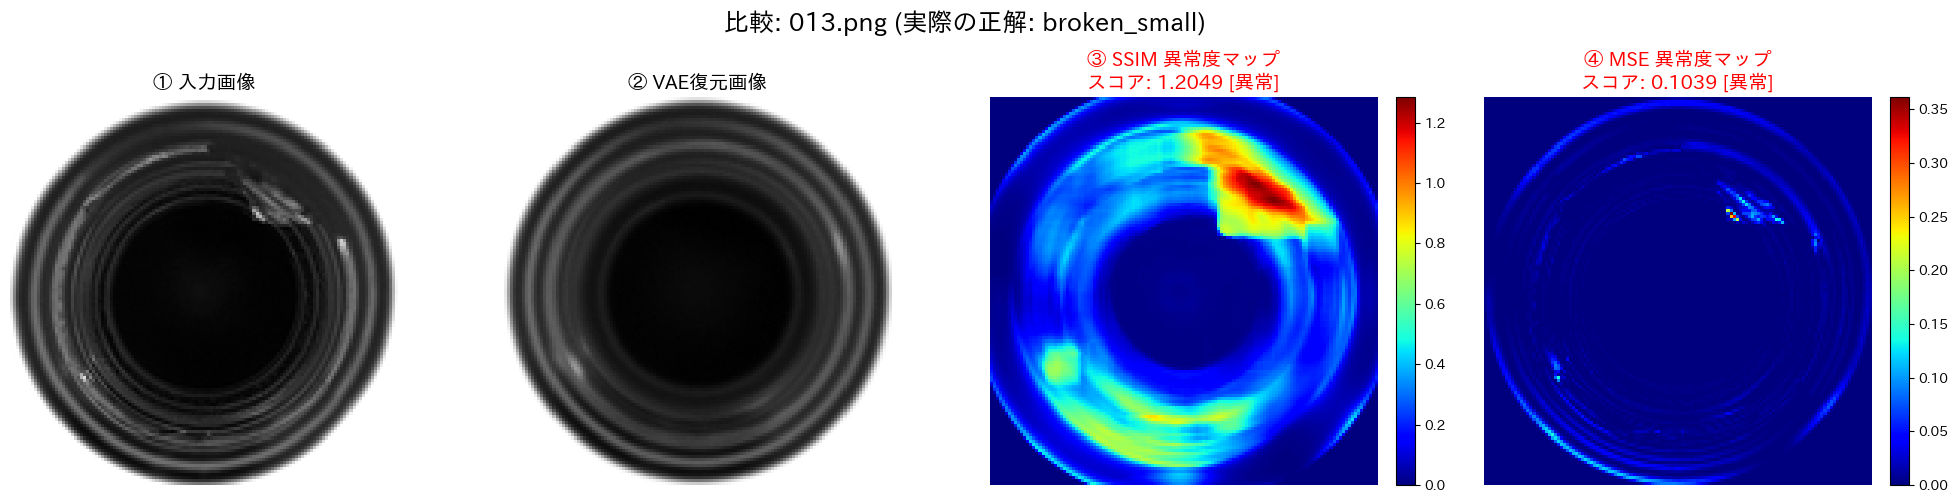

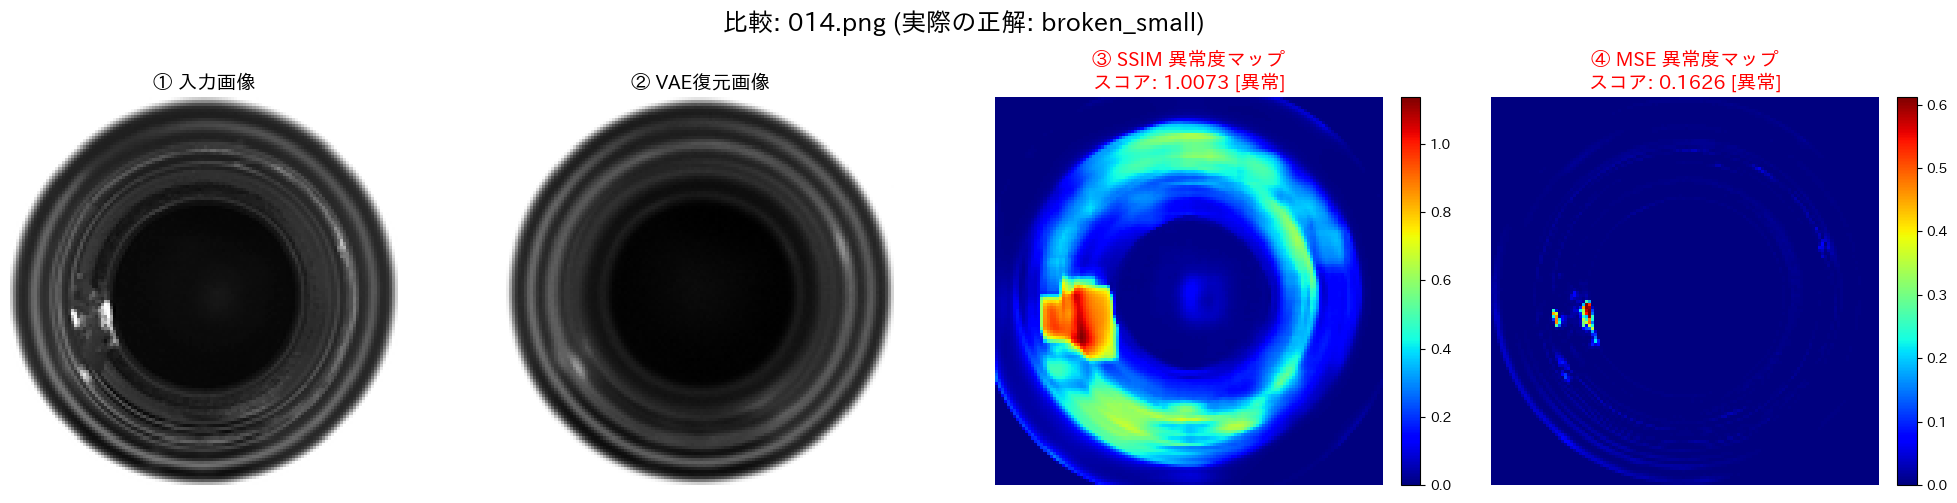

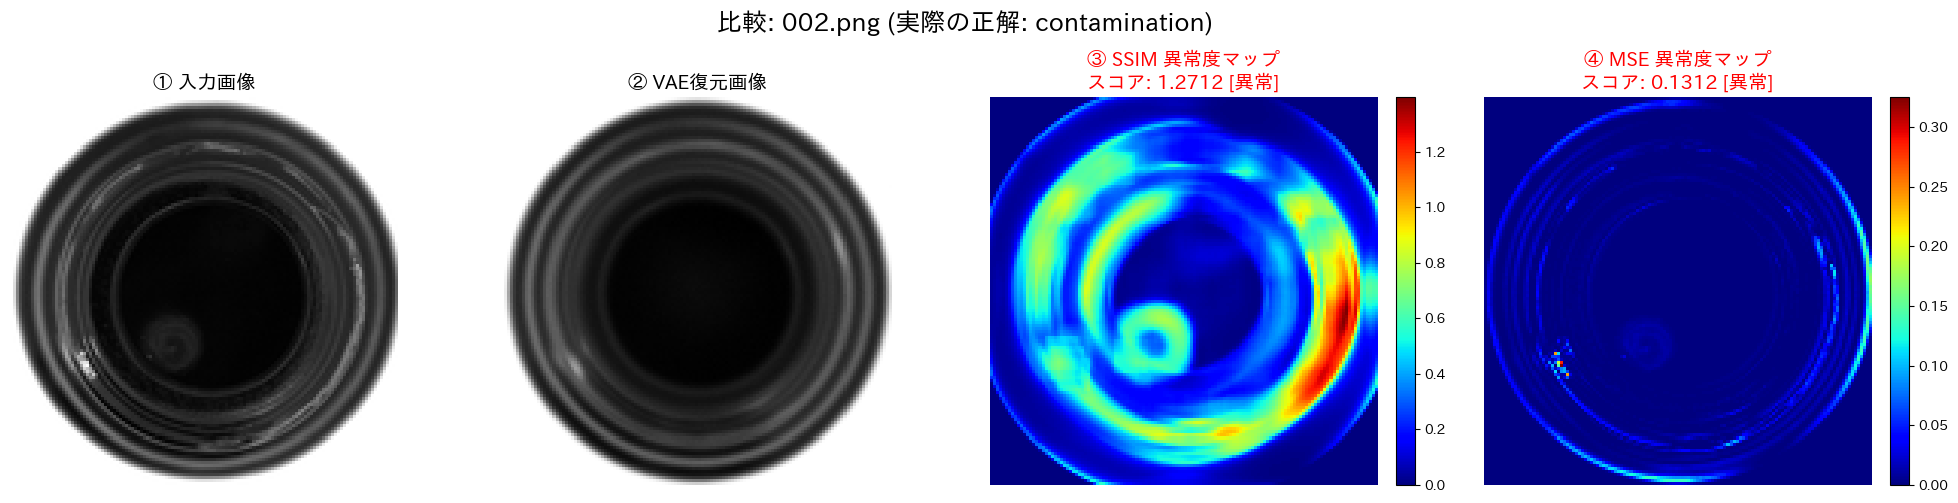


すべての検証プロセスが完了しました。


In [9]:
# =====================================================================
# 検証用コード: 完全結合モデル（FC_Only）版
# 異常スコア: SSIM Top-K vs MSE Top-K の比較検証用
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (FC_Only版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_FC_Only(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_FC_Only, self).__init__()
        
        # 128x128ピクセル = 16384次元の一次元データとして処理
        self.encoder = nn.Sequential(
            nn.Linear(128 * 128, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 128 * 128), nn.Sigmoid()
        )

    def forward(self, x):
        # 2次元の画像データを1次元に平坦化
        x_flat = torch.flatten(x, start_dim=1)
        
        h = self.encoder(x_flat)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        recon_flat = self.decoder(z)
        # 1次元の出力を、元の画像サイズ (バッチサイズ, 1チャンネル, 128, 128) に戻す
        recon = recon_flat.view(-1, 1, 128, 128)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群 (SSIM vs MSE 比較仕様)
# =====================================================================
def evaluate_dataset(model, test_dir, device, threshold_ssim, threshold_mse, top_k=130):
    """データセット全体を推論し、SSIMとMSE両方の評価結果を返す"""
    model.eval()
    y_true = []
    
    y_pred_ssim, scores_ssim = [], []
    y_pred_mse, scores_mse = [], []
    
    all_image_paths = []
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}")

    print(f"テストデータ全件の評価を開始します... (Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir(): continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            
            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                
                recon_tensor, _, _ = model(input_tensor)
                
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()
                
                # --- SSIMの計算 ---
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map_ssim = 1.0 - ssim_map
                top_k_score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
                
                # --- MSEの計算 ---
                anomaly_map_mse = (input_img - recon_img) ** 2
                top_k_score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
                
                pred_ssim = 1 if top_k_score_ssim > threshold_ssim else 0
                pred_mse = 1 if top_k_score_mse > threshold_mse else 0
                
                y_true.append(true_label)
                all_image_paths.append(img_path)
                
                y_pred_ssim.append(pred_ssim)
                scores_ssim.append(top_k_score_ssim)
                
                y_pred_mse.append(pred_mse)
                scores_mse.append(top_k_score_mse)
                
    print("評価が完了しました。")
    return (np.array(y_true), np.array(y_pred_ssim), np.array(scores_ssim), 
            np.array(y_pred_mse), np.array(scores_mse), all_image_paths)

def print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, th_ssim, th_mse, top_k):
    """SSIMとMSEの評価指標を計算し、混同行列を並べて描画する"""
    
    def calc_metrics(y_t, y_p):
        return {
            'acc': accuracy_score(y_t, y_p) * 100,
            'prec': precision_score(y_t, y_p, zero_division=0) * 100,
            'rec': recall_score(y_t, y_p, zero_division=0) * 100,
            'f1': f1_score(y_t, y_p, zero_division=0) * 100
        }
    
    m_ssim = calc_metrics(y_true, y_pred_ssim)
    m_mse = calc_metrics(y_true, y_pred_mse)
    
    print(f"\n{'='*40}")
    print(f"定量評価結果 (Top-{top_k} パッチ)")
    print(f"{'='*40}")
    print(f"[SSIM 異常検知] 閾値: {th_ssim}")
    print(f" - 正解率 (Accuracy) : {m_ssim['acc']:.2f}%")
    print(f" - 適合率 (Precision): {m_ssim['prec']:.2f}%")
    print(f" - 再現率 (Recall)   : {m_ssim['rec']:.2f}%")
    print(f" - F値    (F1-score) : {m_ssim['f1']:.2f}%")
    print("-" * 40)
    print(f"[MSE 異常検知] 閾値: {th_mse}")
    print(f" - 正解率 (Accuracy) : {m_mse['acc']:.2f}%")
    print(f" - 適合率 (Precision): {m_mse['prec']:.2f}%")
    print(f" - 再現率 (Recall)   : {m_mse['rec']:.2f}%")
    print(f" - F値    (F1-score) : {m_mse['f1']:.2f}%")
    print(f"{'='*40}\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_ssim = confusion_matrix(y_true, y_pred_ssim)
    sns.heatmap(cm_ssim, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    axes[0].set_title(f"混同行列 [SSIM]\n(Acc: {m_ssim['acc']:.1f}% | F1: {m_ssim['f1']:.1f}%)", fontsize=16)
    axes[0].set_xlabel('AIの予測')
    axes[0].set_ylabel('実際の正解')
    
    cm_mse = confusion_matrix(y_true, y_pred_mse)
    sns.heatmap(cm_mse, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    axes[1].set_title(f"混同行列 [MSE]\n(Acc: {m_mse['acc']:.1f}% | F1: {m_mse['f1']:.1f}%)", fontsize=16)
    axes[1].set_xlabel('AIの予測')
    axes[1].set_ylabel('実際の正解')
    
    plt.tight_layout()
    plt.show()

def plot_score_distributions(y_true, scores_ssim, scores_mse, th_ssim, th_mse, top_k):
    """SSIMとMSEのスコア分布を並べて描画する"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    def plot_hist(ax, scores, th, title, xlabel, color_normal, color_anomaly, th_color):
        norm_scores = scores[y_true == 0]
        anom_scores = scores[y_true == 1]
        bins = np.linspace(np.min(scores), np.max(scores), 40)
        
        sns.histplot(norm_scores, bins=bins, color=color_normal, alpha=0.5, label='正常 (Good)', kde=False, ax=ax)
        sns.histplot(anom_scores, bins=bins, color=color_anomaly, alpha=0.5, label='異常 (Anomaly)', kde=False, ax=ax)
        ax.axvline(x=th, color=th_color, linestyle='--', linewidth=2, label=f'閾値 ({th})')
        
        ax.set_title(title, fontsize=15, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("画像の数", fontsize=12)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plot_hist(axes[0], scores_ssim, th_ssim, f"SSIM 異常スコア分布 (Top-{top_k})", "異常スコア (1-SSIM)", 'green', 'red', 'blue')
    plot_hist(axes[1], scores_mse, th_mse, f"MSE 異常スコア分布 (Top-{top_k})", "異常スコア (MSE)", 'teal', 'orange', 'red')
    
    plt.tight_layout()
    plt.show()

def plot_anomaly_comparison(model, image_path, device, th_ssim, th_mse, top_k=130):
    """1枚の画像に対し、SSIMとMSEの異常度マップを比較表示する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)
        
    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()
    
    # SSIM計算
    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map_ssim = 1.0 - ssim_map
    score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
    judgement_ssim = "異常" if score_ssim > th_ssim else "正常"
    color_ssim = 'red' if score_ssim > th_ssim else 'green'
    
    # MSE計算
    anomaly_map_mse = (input_img - recon_img) ** 2
    score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
    judgement_mse = "異常" if score_mse > th_mse else "正常"
    color_mse = 'red' if score_mse > th_mse else 'green'

    # 描画
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"比較: {image_path.name} (実際の正解: {image_path.parent.name})", fontsize=18, fontweight='bold')
    
    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')
    
    vmax_ssim = max(np.max(anomaly_map_ssim), 0.1)
    im3 = axes[2].imshow(anomaly_map_ssim, cmap='jet', vmin=0, vmax=vmax_ssim)
    axes[2].set_title(f"③ SSIM 異常度マップ\nスコア: {score_ssim:.4f} [{judgement_ssim}]", fontsize=14, color=color_ssim)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    vmax_mse = max(np.max(anomaly_map_mse), 0.05)
    im4 = axes[3].imshow(anomaly_map_mse, cmap='jet', vmin=0, vmax=vmax_mse)
    axes[3].set_title(f"④ MSE 異常度マップ\nスコア: {score_mse:.4f} [{judgement_mse}]", fontsize=14, color=color_mse)
    axes[3].axis('off')
    fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")
    
    # モデルのインスタンス化を FC_Only 版に変更
    model = VAE_FC_Only(latent_dim=64).to(device)
    
    # r"..." を使用してWindowsのパス区切り文字をそのまま扱う
    MODEL_PATH = r"C:\Users\tokiy\my_GItHub\image-anomaly-detection\saved_models\vae_FC_Only_Annealing_ep100_beta50_128.pth"
    
    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}")
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"モデルの重みを読み込みました。\n")
    
    TEST_DIR = r"C:\Users\tokiy\my_GItHub\image-anomaly-detection\data\bottle\test"
    
    # -------------------------------------------------------------
    # ★ パラメータ設定 ★
    # -------------------------------------------------------------
    TOP_K = 130
    THRESHOLD_SSIM = 0.9
    THRESHOLD_MSE = 0.1  # ヒストグラムの分布を見て適宜微調整してください
    
    # 評価実行
    (y_true, y_pred_ssim, scores_ssim, 
     y_pred_mse, scores_mse, all_image_paths) = evaluate_dataset(
         model, TEST_DIR, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)
    
    # 定量評価と混同行列
    print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    # スコア分布比較
    plot_score_distributions(y_true, scores_ssim, scores_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    print("\n--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---")
    normal_paths = [p for t, p in zip(y_true, all_image_paths) if t == 0]
    anomaly_paths = [p for t, p in zip(y_true, all_image_paths) if t == 1]
    
    sample_paths = []
    if normal_paths: sample_paths.extend(random.sample(normal_paths, min(2, len(normal_paths))))
    if anomaly_paths: sample_paths.extend(random.sample(anomaly_paths, min(3, len(anomaly_paths))))
    
    for img_path in sample_paths:
        plot_anomaly_comparison(model, img_path, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)

    print("\nすべての検証プロセスが完了しました。")